<a href="https://colab.research.google.com/github/mikhael2104/Kecerdasan-Buatan/blob/main/Jobsheet_07.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Mikhael Surya Adeputra
- **NIM:** 4.33.25.0.13
- **Kelas:** TI-1A

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1
Kategori produk apa yang menghasilkan total pendapatan (revenue) tertinggi dan terendah?

- Pertanyaan 2
Bagaimana tingkat kepuasan pelanggan (review score) terhadap performa pengiriman pesanan yang tepat waktu dibandingkan yang terlambat?

## Import Semua Packages/Library yang Digunakan

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style visualisasi
sns.set_theme(style="whitegrid")

## Data Wrangling

### Gathering Data

In [6]:
import numpy as np
import pandas as pd

# Load dataset
customers_df = pd.read_csv("customers_dataset.csv")
orders_df = pd.read_csv("orders_dataset.csv")
order_items_df = pd.read_csv("order_items_dataset.csv")
products_df = pd.read_csv("products_dataset.csv")

# Tampilkan beberapa baris pertama dari tabel utama
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### Assessing Data

In [7]:
# 1. Memeriksa tipe data dan missing values pada setiap DataFrame
print("--- Info Orders ---")
orders_df.info()

print("\n--- Info Order Items ---")
order_items_df.info()

# 2. Memeriksa jumlah duplikasi data
print("\nJumlah duplikasi pada Orders:", orders_df.duplicated().sum())

# 3. Memeriksa statistik deskriptif untuk deteksi anomali/outlier
print("\n--- Deskripsi Produk ---")
products_df.describe()

--- Info Orders ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB

--- Info Order Items ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0  

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


### Cleaning Data

In [8]:
# 1. Mengubah kolom tanggal dari objek/string menjadi datetime
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in datetime_columns:
    orders_df[col] = pd.to_datetime(orders_df[col])

# 2. Menangani missing values pada baris tanggal yang kosong
orders_df.dropna(subset=["order_delivered_customer_date"], inplace=True)

# 3. Verifikasi hasil pembersihan data
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96476 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96476 non-null  object        
 1   customer_id                    96476 non-null  object        
 2   order_status                   96476 non-null  object        
 3   order_purchase_timestamp       96476 non-null  datetime64[ns]
 4   order_approved_at              96462 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96475 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96476 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


## Exploratory Data Analysis (EDA)

### Explore ...

In [9]:
# 1. Menggabungkan data pesanan dengan detail item dan produk
all_df = pd.merge(
    left=orders_df,
    right=order_items_df,
    how="inner",
    on="order_id"
)

all_df = pd.merge(
    left=all_df,
    right=products_df,
    how="inner",
    on="product_id"
)

# 2. Pivot Table: Melihat ringkasan penjualan per kategori produk (Revenue & Total Order)
product_summary = all_df.groupby("product_category_name").agg({
    "order_id": "nunique",
    "price": "sum"
}).reset_index().rename(columns={
    "order_id": "total_orders",
    "price": "total_revenue"
}).sort_values(by="total_revenue", ascending=False)

# Tampilkan 5 kategori dengan revenue tertinggi
product_summary.head()

,product_category_name,total_orders,total_revenue
11,beleza_saude,8649,1233211.61
66,relogios_presentes,5493,1165898.98
13,cama_mesa_banho,9272,1023434.76
32,esporte_lazer,7530,954695.05
44,informatica_acessorios,6529,888613.62


In [10]:
# 3. Pivot Table: Analisis waktu pengiriman vs estimasi
all_df['delivery_time_days'] = (all_df['order_delivered_customer_date'] - all_df['order_purchase_timestamp']).dt.days
all_df['estimated_vs_actual'] = (all_df['order_estimated_delivery_date'] - all_df['order_delivered_customer_date']).dt.days

# Kategori ketepatan pengiriman
all_df['is_late'] = all_df['estimated_vs_actual'].apply(lambda x: "Terlambat" if x < 0 else "Tepat Waktu")

# Tampilkan distribusi status pengiriman
all_df['is_late'].value_counts()

,count
is_late,
Tepat Waktu,101481
Terlambat,8715


## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_1248/3234480652.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_1248/3234480652.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


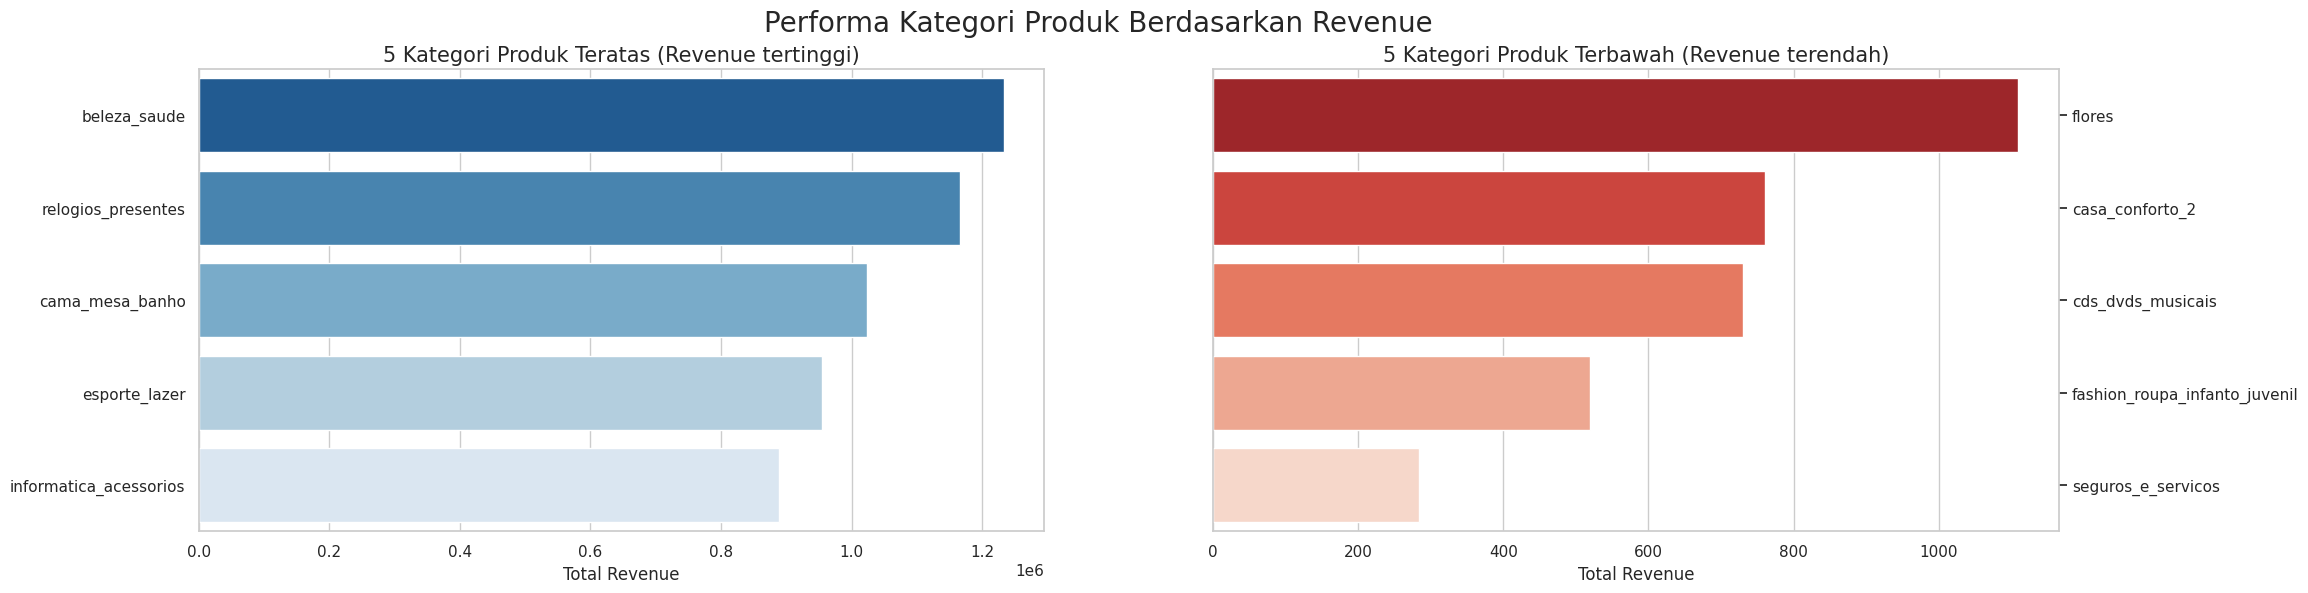

In [13]:
# Sesuaikan baris ini dengan nama variabel yang kamu pakai di cell sebelumnya
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

# Top 5 Produk
sns.barplot(
    x="total_revenue",
    y="product_category_name",
    data=product_summary.head(5), # Sesuai nama variabelmu
    palette="Blues_r",
    ax=ax[0]
)
ax[0].set_ylabel(None)
ax[0].set_xlabel("Total Revenue", fontsize=12)
ax[0].set_title("5 Kategori Produk Teratas (Revenue tertinggi)", loc="center", fontsize=15)

# Bottom 5 Produk
sns.barplot(
    x="total_revenue",
    y="product_category_name",
    data=product_summary.tail(5), # Sesuai nama variabelmu
    palette="Reds_r",
    ax=ax[1]
)
ax[1].set_ylabel(None)
ax[1].set_xlabel("Total Revenue", fontsize=12)
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("5 Kategori Produk Terbawah (Revenue terendah)", loc="center", fontsize=15)

plt.suptitle("Performa Kategori Produk Berdasarkan Revenue", fontsize=20)
plt.show()

### Pertanyaan 2:

In [18]:
# 1. Load data review jika belum
order_reviews_df = pd.read_csv("order_reviews_dataset.csv")

# 2. Merge tabel orders_df dengan order_reviews_df berdasarkan 'order_id'
orders_df = pd.merge(orders_df, order_reviews_df, on="order_id", how="inner")

# 3. Hitung selisih hari & buat kolom delivery_status
orders_df['delivery_delay'] = (orders_df['order_delivered_customer_date'] - orders_df['order_estimated_delivery_date']).dt.days
orders_df['delivery_status'] = orders_df['delivery_delay'].apply(lambda x: 'Terlambat' if x > 0 else 'Tepat Waktu')

/tmp/ipykernel_1248/160015102.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


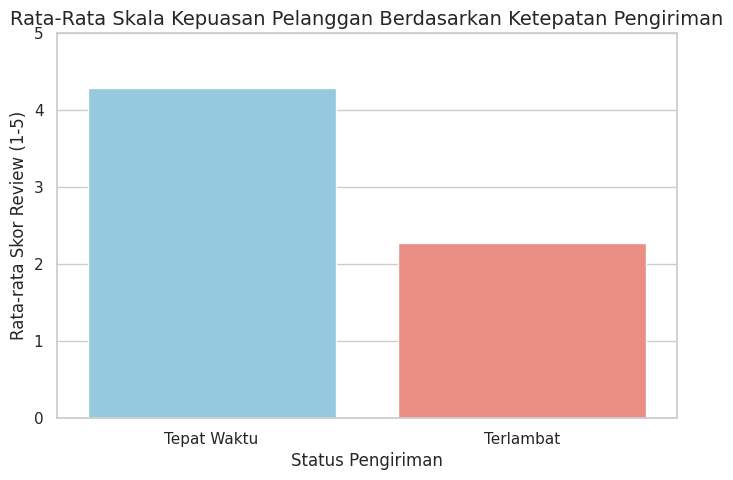

In [19]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x="delivery_status",
    y="review_score",
    data=orders_df,
    palette={"Tepat Waktu": "skyblue", "Terlambat": "salmon"},
    errorbar=None
)
plt.title("Rata-Rata Skala Kepuasan Pelanggan Berdasarkan Ketepatan Pengiriman", fontsize=14)
plt.xlabel("Status Pengiriman", fontsize=12)
plt.ylabel("Rata-rata Skor Review (1-5)", fontsize=12)
plt.ylim(0, 5)
plt.show()